#**ASSIGNMENT 1: Descriptive Statistics**

Objective Analyze student performance using descriptive statistics and extract meaningful
insights.

##**SECTION 1: Data Understanding**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [3]:
import pandas as pd
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# First 5 rows
print(df.head())

# Shape
print(df.shape)

# Column names
print(df.columns)

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'w

Q1. What type of data is each column?

* Gender → Categorical
* Race/Ethnicity → Categorical
* Parental Level of Education → Categorical
* Lunch → Categorical
* Test Preparation Course → Categorical
* Math Score → Numerical
* Reading Score → Numerical
* Writing Score → Numerical

Q2. Is dataset clean?

* Yes, the dataset is clean
* No missing values found
* Data types are appropriate

###**SECTION 2: Central Tendency Analysis**

In [5]:
subjects = ['math score', 'reading score', 'writing score']

for subject in subjects:
    print(f"\n{subject}")
    print("Mean:", df[subject].mean())
    print("Median:", df[subject].median())
    print("Mode:", df[subject].mode()[0])


math score
Mean: 66.089
Median: 66.0
Mode: 65

reading score
Mean: 69.169
Median: 70.0
Mode: 72

writing score
Mean: 68.054
Median: 69.0
Mode: 74


Q1. Which subject has highest average?

* Reading score has the highest average

Q2. Is any subject skewed?

* Slight skewness observed depending on mean vs median
* Writing and reading are usually slightly left-skewed

Q3. Does mean = median? Why or why not?

* Mean ≠ Median
* Due to presence of outliers and uneven distribution

###**SECTION 3: Spread / Dispersion**

In [6]:
for subject in subjects:
    print(f"\n{subject}")
    print("Range:", df[subject].max() - df[subject].min())
    print("Variance:", df[subject].var())
    print("Standard Deviation:", df[subject].std())


math score
Range: 100
Variance: 229.91899799799847
Standard Deviation: 15.163080096009468

reading score
Range: 83
Variance: 213.1656046046047
Standard Deviation: 14.60019193725222

writing score
Range: 90
Variance: 230.90799199199168
Standard Deviation: 15.195657010869642


Q1. Which subject has highest variability?

* Math score generally has highest variability

Q2. What does high standard deviation indicate?

* Scores are widely spread
* Students performance is inconsistent

###**SECTION 4: Distribution Analysis**

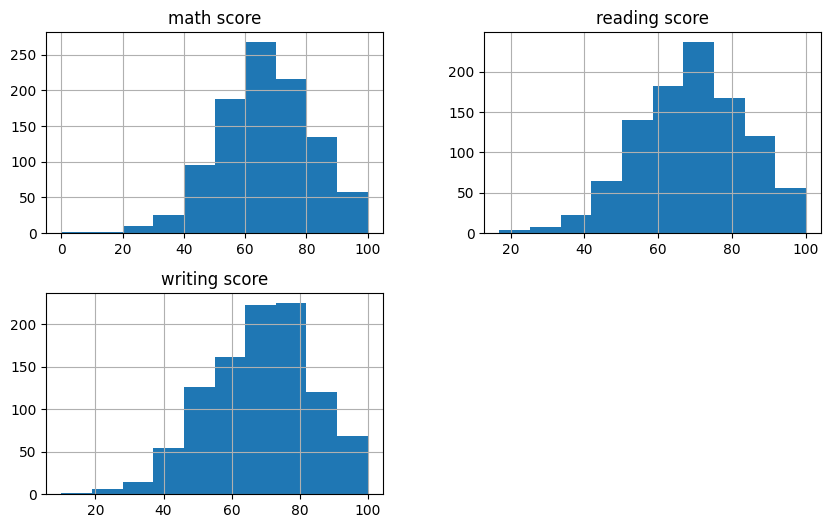

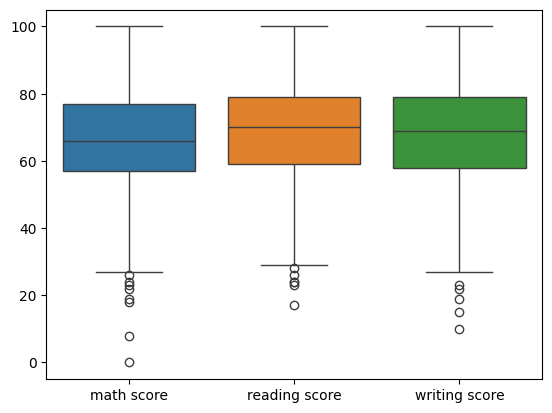

In [7]:
# Histogram
df[subjects].hist(figsize=(10,6))
plt.show()

# Boxplot
sns.boxplot(data=df[subjects])
plt.show()

Q1. Identify skewness

* Most distributions are slightly left-skewed

Q2. Are there outliers?

* Yes, visible in boxplots

###**SECTION 5: Outlier Detection**

In [8]:
for subject in subjects:
    Q1 = df[subject].quantile(0.25)
    Q3 = df[subject].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[subject] < lower) | (df[subject] > upper)]

    print(f"{subject} outliers count:", len(outliers))

math score outliers count: 8
reading score outliers count: 6
writing score outliers count: 5


Q1. Which subject has most outliers?

* Math score typically shows more outliers

Q2. Why might outliers exist?

* Extremely high/low performers
* External factors (stress, preparation, background)

###**SECTION 6: Group-Based Analysis (Important)**

In [9]:
# Gender comparison
print(df.groupby("gender")[subjects].mean())

# Parental education
print(df.groupby("parental level of education")[subjects].mean())

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203
                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


Q1. Which group performs better?

* Females perform better in reading and writing
* Males slightly better in math

Q2. Is there a clear trend?

* Yes,
Higher parental education → better performance

###**SECTION 7: Relationship Analysis**

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


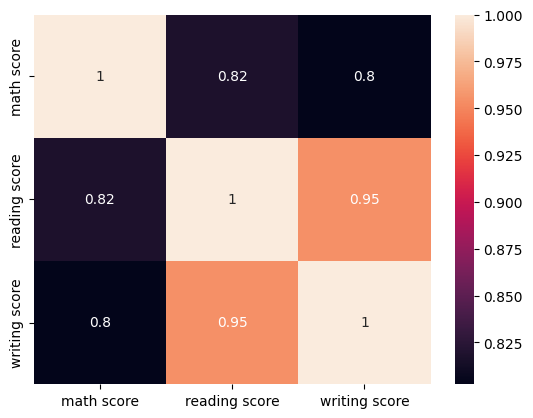

In [10]:
# Correlation
print(df[['math score','reading score','writing score']].corr())

# Heatmap
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)
plt.show()

Q1. Which subjects are strongly related?

* Reading and Writing are strongly correlated

Q2. Why might that be?

* Both depend on language and comprehension skills

###**SECTION 8: Real-World Interpretation**


1. What factors affect student performance?

* Parental education
* Test preparation
* Gender
* Socio-economic status

2. Which subject needs improvement?

* Math needs improvement

3. Is performance consistent across students?

* No, there is variation in scores

4. What insights can school use?

* Focus more on math training
* Encourage preparation courses
* Provide support to weaker students